In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'

import torch
torch.set_num_threads(1)
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from pathlib import Path
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from torch.utils.data import Dataset, DataLoader

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DATA = Path('../../data/processed')
MODELS = Path('../../data/models')
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')

PyTorch 2.10.0 | Device: mps


In [3]:
WINDOW = 48
HORIZON = 12
MIN_SEQ_LEN = WINDOW + HORIZON + 10
N_FEATURES = 4

prices = pd.read_parquet(DATA / 'prices.parquet')
print(f'Загружено: {len(prices):,} точек, {prices.token_id.nunique()} рынков')

def create_features(price_series):
    df = pd.DataFrame({'price': price_series.values})
    df['ret'] = df['price'].diff().fillna(0)
    df['vol'] = df['ret'].rolling(12, min_periods=1).std().fillna(0)
    df['momentum'] = df['price'] - df['price'].rolling(12, min_periods=1).mean()
    df['momentum'] = df['momentum'].fillna(0)
    return df[['price', 'ret', 'vol', 'momentum']].values

def create_sequences(prices_df, window=WINDOW, horizon=HORIZON):
    all_X, all_y = [], []
    for token_id, group in prices_df.groupby('token_id'):
        ts = group.sort_values('datetime')
        if len(ts) < MIN_SEQ_LEN:
            continue
        features = create_features(ts['price'])
        prices_arr = ts['price'].values
        for i in range(0, len(features) - window - horizon, 6):
            X = features[i : i + window]
            current_price = prices_arr[i + window - 1]
            future_price = prices_arr[i + window + horizon - 1]
            y = 1.0 if future_price > current_price else 0.0
            all_X.append(X)
            all_y.append(y)
    return np.array(all_X, dtype=np.float32), np.array(all_y, dtype=np.float32)

X, y = create_sequences(prices)
print(f'Dataset: X={X.shape}, y={y.shape}')
print(f'Class balance: UP={y.mean():.1%}, DOWN={1-y.mean():.1%}')

Загружено: 1,681,266 точек, 1000 рынков


Dataset: X=(270589, 48, 4), y=(270589,)
Class balance: UP=33.4%, DOWN=66.6%


In [4]:
n = len(X)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

train_mean = X_train.reshape(-1, N_FEATURES).mean(axis=0)
train_std = X_train.reshape(-1, N_FEATURES).std(axis=0) + 1e-8

X_train_norm = (X_train - train_mean) / train_std
X_val_norm = (X_val - train_mean) / train_std
X_test_norm = (X_test - train_mean) / train_std

print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')
print(f'Формат Transformer: (batch, seq_len={WINDOW}, features={N_FEATURES}) → проекция в d_model')

Train: 189,412 | Val: 40,588 | Test: 40,589
Формат Transformer: (batch, seq_len=48, features=4) → проекция в d_model


In [5]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 256

train_ds = TimeSeriesDataset(X_train_norm, y_train)
val_ds = TimeSeriesDataset(X_val_norm, y_val)
test_ds = TimeSeriesDataset(X_test_norm, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE * 2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE * 2)

batch_X, batch_y = next(iter(train_loader))
print(f'Batch X: {batch_X.shape}  → (batch, seq_len={WINDOW}, features={N_FEATURES})')
print(f'Batch y: {batch_y.shape}')

Batch X: torch.Size([256, 48, 4])  → (batch, seq_len=48, features=4)
Batch y: torch.Size([256])


In [6]:
np.random.seed(SEED)
mr_prob = 1 - 1 / (1 + np.exp(-X_test[:, -6:, 1].sum(axis=1) * 50))

results = {}
results['Random'] = {'auc': 0.5, 'acc': 0.5}
results['Mean Reversion'] = {
    'auc': roc_auc_score(y_test, mr_prob),
    'acc': accuracy_score(y_test, (X_test[:, -1, 1] < 0).astype(float))
}
results['LSTM (nb03)'] = {'auc': 0.6598, 'acc': 0.678}
results['GRU (nb03)'] = {'auc': 0.6661, 'acc': 0.678}
results['CNN (nb04)'] = {'auc': 0.6685, 'acc': 0.679}
results['ResCNN (nb04)'] = {'auc': 0.6754, 'acc': 0.680}

print('Baselines и предыдущие результаты:')
for name, m in sorted(results.items(), key=lambda x: x[1]['auc'], reverse=True):
    print(f'  {name:<20} AUC={m["auc"]:.4f}  Acc={m["acc"]:.1%}')

Baselines и предыдущие результаты:
  ResCNN (nb04)        AUC=0.6754  Acc=68.0%
  CNN (nb04)           AUC=0.6685  Acc=67.9%
  GRU (nb03)           AUC=0.6661  Acc=67.8%
  LSTM (nb03)          AUC=0.6598  Acc=67.8%
  Mean Reversion       AUC=0.5585  Acc=66.4%
  Random               AUC=0.5000  Acc=50.0%


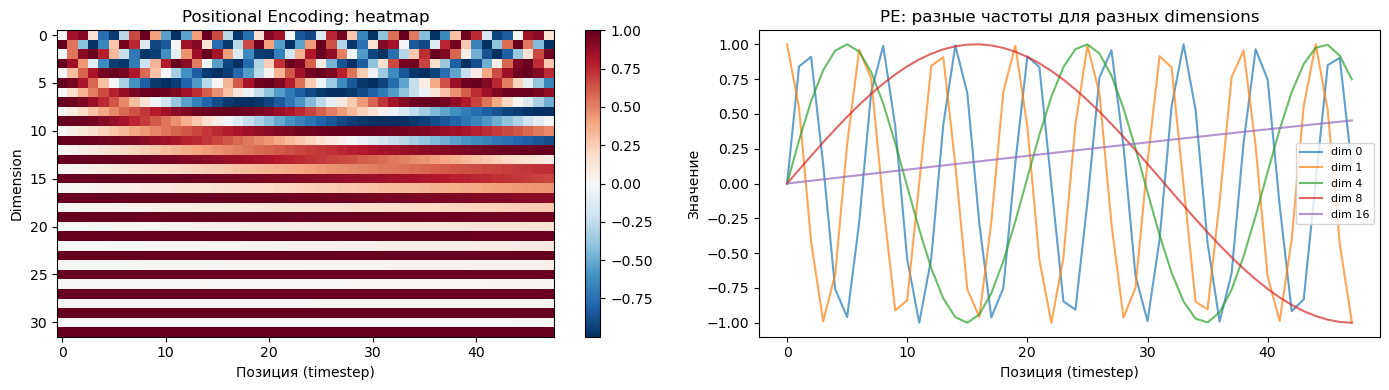

Низкие dimensions = высокая частота (различают соседние позиции)
Высокие dimensions = низкая частота (различают далёкие позиции)


In [7]:
class PositionalEncoding(nn.Module):
    """Синусоидальное позиционное кодирование."""
    def __init__(self, d_model, max_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):

        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

pe_vis = PositionalEncoding(d_model=32, max_len=48)
pe_matrix = pe_vis.pe[0, :48].numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

im = axes[0].imshow(pe_matrix.T, aspect='auto', cmap='RdBu_r')
axes[0].set_xlabel('Позиция (timestep)')
axes[0].set_ylabel('Dimension')
axes[0].set_title('Positional Encoding: heatmap')
plt.colorbar(im, ax=axes[0])

for d in [0, 1, 4, 8, 16]:
    axes[1].plot(pe_matrix[:, d], label=f'dim {d}', alpha=0.7)
axes[1].set_xlabel('Позиция (timestep)')
axes[1].set_ylabel('Значение')
axes[1].set_title('PE: разные частоты для разных dimensions')
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()
print('Низкие dimensions = высокая частота (различают соседние позиции)')
print('Высокие dimensions = низкая частота (различают далёкие позиции)')

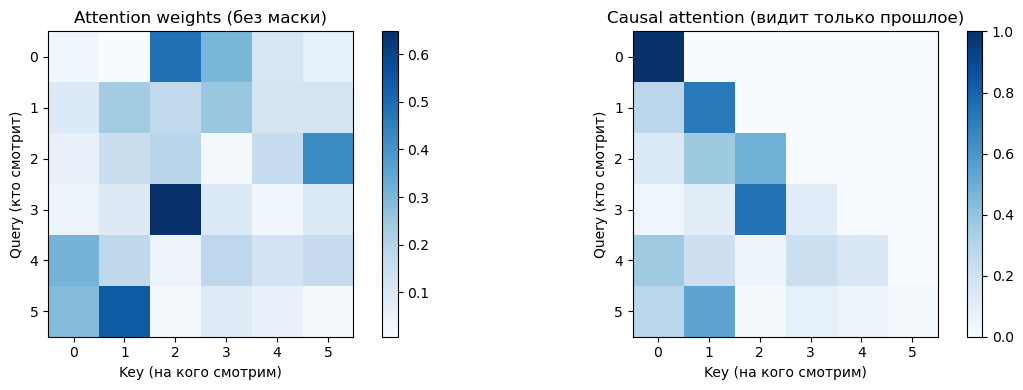

Attention weights shape: torch.Size([1, 1, 6, 6]) → (batch, heads, seq_len, seq_len)


Каждая строка = softmax → сумма = 1.0
Causal mask: нижний треугольник (будущее = 0)


In [8]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q, K, V: (batch, heads, seq_len, d_k)
    Returns: output (batch, heads, seq_len, d_k), weights (batch, heads, seq_len, seq_len)
    """
    d_k = Q.size(-1)

    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))

    weights = F.softmax(scores, dim=-1)

    output = torch.matmul(weights, V)

    return output, weights

torch.manual_seed(42)
batch, seq_len, d_k = 1, 6, 8
Q = torch.randn(batch, 1, seq_len, d_k)
K = torch.randn(batch, 1, seq_len, d_k)
V = torch.randn(batch, 1, seq_len, d_k)

out, weights = scaled_dot_product_attention(Q, K, V)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im1 = axes[0].imshow(weights[0, 0].numpy(), cmap='Blues')
axes[0].set_xlabel('Key (на кого смотрим)')
axes[0].set_ylabel('Query (кто смотрит)')
axes[0].set_title('Attention weights (без маски)')
plt.colorbar(im1, ax=axes[0])

causal_mask = torch.tril(torch.ones(seq_len, seq_len)).unsqueeze(0).unsqueeze(0)
out_causal, weights_causal = scaled_dot_product_attention(Q, K, V, mask=causal_mask)

im2 = axes[1].imshow(weights_causal[0, 0].numpy(), cmap='Blues')
axes[1].set_xlabel('Key (на кого смотрим)')
axes[1].set_ylabel('Query (кто смотрит)')
axes[1].set_title('Causal attention (видит только прошлое)')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout(); plt.show()
print(f'Attention weights shape: {weights.shape} → (batch, heads, seq_len, seq_len)')
print(f'Каждая строка = softmax → сумма = {weights[0,0,0].sum().item():.1f}')
print(f'Causal mask: нижний треугольник (будущее = 0)')

In [9]:
class PriceTransformer(nn.Module):
    """Transformer encoder для предсказания направления цены."""

    def __init__(self, in_features=4, d_model=32, nhead=4, num_layers=2,
                 dim_feedforward=128, dropout=0.1):
        super().__init__()

        self.input_proj = nn.Linear(in_features, d_model)

        self.pos_encoder = PositionalEncoding(d_model, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1)
        )

    def forward(self, x):

        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.classifier(x).squeeze(-1)

model = PriceTransformer(in_features=N_FEATURES).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'PriceTransformer: {total_params:,} параметров')
print(f'\nАрхитектура:')
print(model)

with torch.no_grad():
    out = model(batch_X.to(DEVICE))
    print(f'\nForward: {batch_X.shape} → {out.shape}')

print(f'\nСравнение параметров:')
print(f'  LSTM (nb03):     ~15K')
print(f'  CNN (nb04):      ~37K')
print(f'  Transformer:     ~{total_params//1000}K')

PriceTransformer: 25,665 параметров

Архитектура:
PriceTransformer(
  (input_proj): Linear(in_features=4, out_features=32, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): LayerNorm((32,), eps=1e-05, elementwise_

/var/folders/qw/dzzvs80x2x5_74jbksl4n2h40000gn/T/ipykernel_11579/3222302820.py:23: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)



Forward: torch.Size([256, 48, 4]) → torch.Size([256])

Сравнение параметров:
  LSTM (nb03):     ~15K
  CNN (nb04):      ~37K
  Transformer:     ~25K


In [10]:
criterion = nn.BCEWithLogitsLoss()

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        total_loss += loss.item() * len(y_batch)
        all_preds.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(y_batch.cpu().numpy())
    preds = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    avg_loss = total_loss / len(labels)
    auc = roc_auc_score(labels, preds)
    acc = accuracy_score(labels, (preds > 0.5).astype(int))
    return avg_loss, auc, acc, preds, labels

def train_model(model, name, epochs=25, lr=1e-3, patience=5):
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
    best_auc = 0
    no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

    for epoch in range(epochs):
        model.train()
        total_loss, n_samples = 0, 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            opt.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            total_loss += loss.item() * len(y_b)
            n_samples += len(y_b)

        train_loss = total_loss / n_samples
        val_loss, val_auc, val_acc, _, _ = evaluate(model, val_loader)
        sched.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)

        improved = val_auc > best_auc
        if improved:
            best_auc = val_auc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        lr_now = opt.param_groups[0]['lr']
        print(f'  Epoch {epoch+1:2d}/{epochs} | Train: {train_loss:.4f} | '
              f'Val: {val_loss:.4f} | AUC: {val_auc:.4f} | LR: {lr_now:.1e} '
              f'{"★" if improved else ""}')

        if no_improve >= patience:
            print(f'  Early stopping at epoch {epoch+1}')
            break

    model.load_state_dict(best_state)
    test_loss, test_auc, test_acc, preds, labels = evaluate(model, test_loader)
    print(f'  → {name}: Val AUC={best_auc:.4f} | Test AUC={test_auc:.4f} | Acc={test_acc:.1%}')
    return model, test_auc, test_acc, history, preds

print('Training utilities ready.')

Training utilities ready.


In [11]:
print('=== PriceTransformer (baseline) ===')
torch.manual_seed(SEED)
tf_model, tf_auc, tf_acc, tf_history, tf_preds = train_model(
    PriceTransformer(in_features=N_FEATURES), 'PriceTransformer', epochs=25
)
results['Transformer (baseline)'] = {'auc': tf_auc, 'acc': tf_acc}

torch.save(tf_model.state_dict(), MODELS / 'price_transformer_v1.pt')

=== PriceTransformer (baseline) ===


/var/folders/qw/dzzvs80x2x5_74jbksl4n2h40000gn/T/ipykernel_11579/3222302820.py:23: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


  Epoch  1/25 | Train: 0.6172 | Val: 0.6261 | AUC: 0.6221 | LR: 1.0e-03 ★


  Epoch  2/25 | Train: 0.6106 | Val: 0.6263 | AUC: 0.6264 | LR: 1.0e-03 ★


  Epoch  3/25 | Train: 0.6084 | Val: 0.6197 | AUC: 0.6301 | LR: 1.0e-03 ★


...

  Epoch 22/25 | Train: 0.5977 | Val: 0.6148 | AUC: 0.6433 | LR: 2.5e-04 


  Epoch 23/25 | Train: 0.5978 | Val: 0.6129 | AUC: 0.6452 | LR: 2.5e-04 ★


  Epoch 24/25 | Train: 0.5975 | Val: 0.6139 | AUC: 0.6433 | LR: 2.5e-04 


  Epoch 25/25 | Train: 0.5972 | Val: 0.6141 | AUC: 0.6452 | LR: 2.5e-04 


  → PriceTransformer: Val AUC=0.6452 | Test AUC=0.6683 | Acc=67.9%


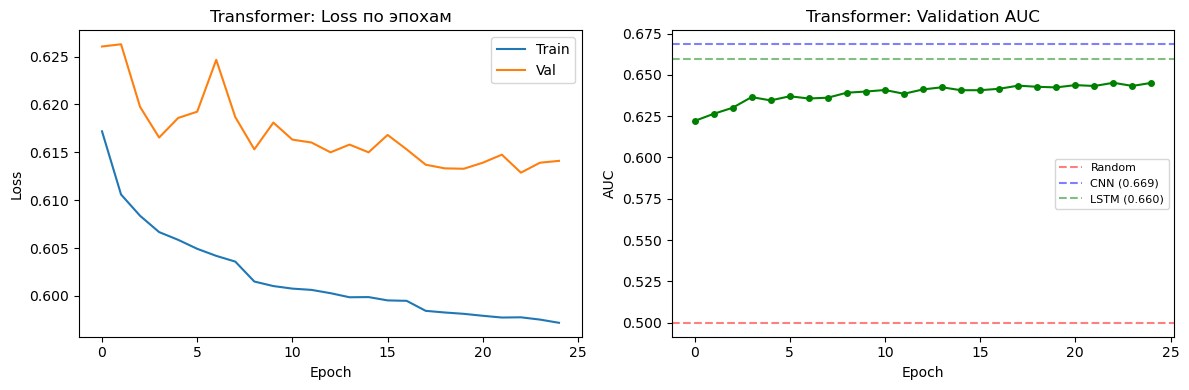

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(tf_history['train_loss'], label='Train')
axes[0].plot(tf_history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Transformer: Loss по эпохам')
axes[0].legend()

axes[1].plot(tf_history['val_auc'], 'g-o', markersize=4)
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Random')
axes[1].axhline(0.6685, color='blue', linestyle='--', alpha=0.5, label='CNN (0.669)')
axes[1].axhline(0.6598, color='green', linestyle='--', alpha=0.5, label='LSTM (0.660)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC')
axes[1].set_title('Transformer: Validation AUC')
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

In [13]:
test_loss, test_auc, test_acc, test_preds_tf, test_labels = evaluate(tf_model, test_loader)

print(f'=== Transformer Test Results ===')
print(f'AUC:      {test_auc:.4f}')
print(f'Accuracy: {test_acc:.1%}')
print(f'Loss:     {test_loss:.4f}')
print(f'\nClassification Report:')
print(classification_report(test_labels, (test_preds_tf > 0.5).astype(int),
                          target_names=['DOWN (0)', 'UP (1)']))

=== Transformer Test Results ===
AUC:      0.6683
Accuracy: 67.9%
Loss:     0.5942

Classification Report:
              precision    recall  f1-score   support

    DOWN (0)       0.69      0.94      0.80     27072
      UP (1)       0.56      0.16      0.25     13517

    accuracy                           0.68     40589
   macro avg       0.63      0.55      0.52     40589
weighted avg       0.65      0.68      0.61     40589



In [14]:
class CLSTransformer(nn.Module):
    """Transformer с CLS token и опциональной causal mask."""

    def __init__(self, in_features=4, d_model=32, nhead=4, num_layers=2,
                 dim_feedforward=128, dropout=0.1, causal=False):
        super().__init__()
        self.causal = causal
        self.d_model = d_model

        self.input_proj = nn.Linear(in_features, d_model)

        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)

        self.pos_encoder = PositionalEncoding(d_model, max_len=200, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1)
        )

    def forward(self, x):
        B = x.size(0)

        x = self.input_proj(x)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)

        x = self.pos_encoder(x)

        mask = None
        if self.causal:
            seq_len = x.size(1)
            mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(x.device)

        x = self.transformer(x, mask=mask)

        cls_output = x[:, 0]

        return self.classifier(cls_output).squeeze(-1)

for name, kwargs in [
    ('Transformer (mean pool)', {}),
    ('CLSTransformer', {'causal': False}),
    ('CLSTransformer (causal)', {'causal': True}),
]:
    if 'CLS' in name:
        m = CLSTransformer(in_features=N_FEATURES, **kwargs)
    else:
        m = PriceTransformer(in_features=N_FEATURES)
    n_params = sum(p.numel() for p in m.parameters())
    print(f'{name:<30}: {n_params:>8,} params')

Transformer (mean pool)       :   25,665 params
CLSTransformer                :   25,697 params
CLSTransformer (causal)       :   25,697 params


/var/folders/qw/dzzvs80x2x5_74jbksl4n2h40000gn/T/ipykernel_11579/3222302820.py:23: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
/var/folders/qw/dzzvs80x2x5_74jbksl4n2h40000gn/T/ipykernel_11579/1319162313.py:28: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


In [15]:
print('=== CLSTransformer ===')
torch.manual_seed(SEED)
cls_model, cls_auc, cls_acc, cls_history, cls_preds = train_model(
    CLSTransformer(in_features=N_FEATURES, causal=False), 'CLSTransformer', epochs=25
)
results['CLS Transformer'] = {'auc': cls_auc, 'acc': cls_acc}

=== CLSTransformer ===


/var/folders/qw/dzzvs80x2x5_74jbksl4n2h40000gn/T/ipykernel_11579/1319162313.py:28: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


  Epoch  1/25 | Train: 0.6184 | Val: 0.6237 | AUC: 0.6232 | LR: 1.0e-03 ★


  Epoch  2/25 | Train: 0.6114 | Val: 0.6257 | AUC: 0.6252 | LR: 1.0e-03 ★


  Epoch  3/25 | Train: 0.6098 | Val: 0.6195 | AUC: 0.6306 | LR: 1.0e-03 ★


...

  Epoch 22/25 | Train: 0.5989 | Val: 0.6139 | AUC: 0.6436 | LR: 2.5e-04 


  Epoch 23/25 | Train: 0.5989 | Val: 0.6129 | AUC: 0.6445 | LR: 2.5e-04 


  Epoch 24/25 | Train: 0.5990 | Val: 0.6131 | AUC: 0.6450 | LR: 2.5e-04 ★


  Epoch 25/25 | Train: 0.5984 | Val: 0.6132 | AUC: 0.6440 | LR: 2.5e-04 


  → CLSTransformer: Val AUC=0.6450 | Test AUC=0.6696 | Acc=67.7%


In [16]:
print('\n=== CLSTransformer (causal) ===')
torch.manual_seed(SEED)
causal_model, causal_auc, causal_acc, causal_history, causal_preds = train_model(
    CLSTransformer(in_features=N_FEATURES, causal=True), 'CausalTransformer', epochs=25
)
results['Causal Transformer'] = {'auc': causal_auc, 'acc': causal_acc}


=== CLSTransformer (causal) ===


/var/folders/qw/dzzvs80x2x5_74jbksl4n2h40000gn/T/ipykernel_11579/1319162313.py:28: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


  Epoch  1/25 | Train: 0.6380 | Val: 0.6431 | AUC: 0.5000 | LR: 1.0e-03 ★


  Epoch  2/25 | Train: 0.6368 | Val: 0.6436 | AUC: 0.5000 | LR: 1.0e-03 


  Epoch  3/25 | Train: 0.6366 | Val: 0.6438 | AUC: 0.5000 | LR: 1.0e-03 


  Epoch  4/25 | Train: 0.6366 | Val: 0.6431 | AUC: 0.5000 | LR: 1.0e-03 


  Epoch  5/25 | Train: 0.6365 | Val: 0.6432 | AUC: 0.5000 | LR: 5.0e-04 


  Epoch  6/25 | Train: 0.6364 | Val: 0.6444 | AUC: 0.5000 | LR: 5.0e-04 
  Early stopping at epoch 6


  → CausalTransformer: Val AUC=0.5000 | Test AUC=0.5000 | Acc=66.7%


In [17]:
print('=== DeepTransformer (d=48, 3L, 4H) ===')
torch.manual_seed(SEED)
deep_model, deep_auc, deep_acc, deep_history, deep_preds = train_model(
    CLSTransformer(in_features=N_FEATURES, d_model=48, nhead=4, num_layers=3,
                   dim_feedforward=192, dropout=0.15),
    'DeepTransformer', epochs=20, lr=5e-4
)
results['Deep Transformer'] = {'auc': deep_auc, 'acc': deep_acc}

n_params = sum(p.numel() for p in deep_model.parameters())
print(f'\nDeep Transformer: {n_params:,} параметров')

=== DeepTransformer (d=48, 3L, 4H) ===


/var/folders/qw/dzzvs80x2x5_74jbksl4n2h40000gn/T/ipykernel_11579/1319162313.py:28: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


  Epoch  1/20 | Train: 0.6201 | Val: 0.6346 | AUC: 0.6208 | LR: 5.0e-04 ★


  Epoch  2/20 | Train: 0.6128 | Val: 0.6348 | AUC: 0.6241 | LR: 5.0e-04 ★


  Epoch  3/20 | Train: 0.6103 | Val: 0.6287 | AUC: 0.6280 | LR: 5.0e-04 ★


...

  Epoch 17/20 | Train: 0.6014 | Val: 0.6147 | AUC: 0.6428 | LR: 5.0e-04 


  Epoch 18/20 | Train: 0.6007 | Val: 0.6156 | AUC: 0.6427 | LR: 2.5e-04 


  Epoch 19/20 | Train: 0.5990 | Val: 0.6162 | AUC: 0.6438 | LR: 2.5e-04 ★


  Epoch 20/20 | Train: 0.5989 | Val: 0.6136 | AUC: 0.6459 | LR: 2.5e-04 ★


  → DeepTransformer: Val AUC=0.6459 | Test AUC=0.6686 | Acc=67.7%

Deep Transformer: 85,249 параметров


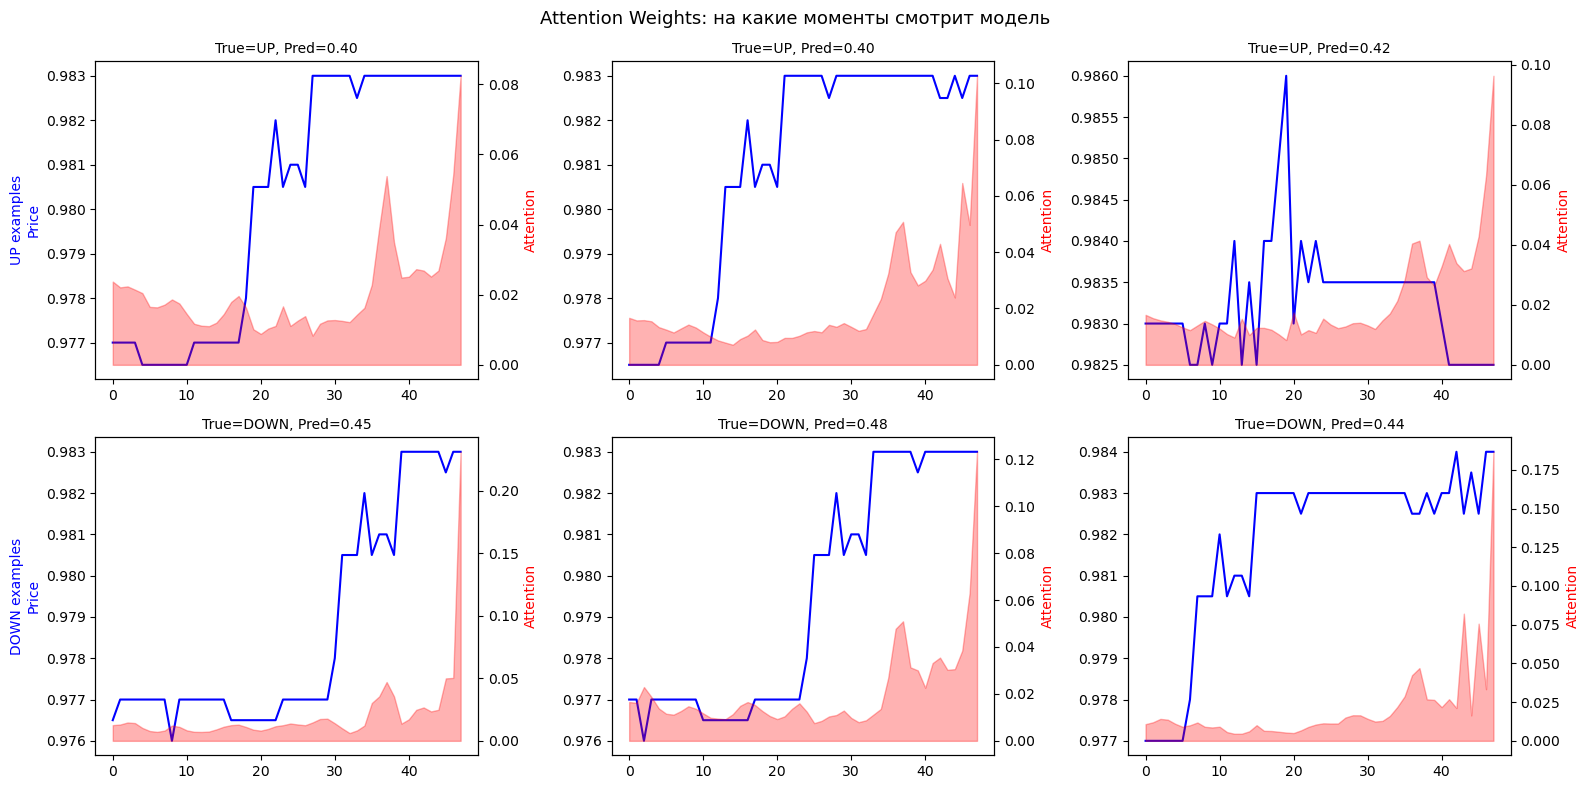

Красная область = высокий attention weight → эти timesteps важны для предсказания.


In [18]:
class AttentionExtractor(nn.Module):
    """Wrapper для извлечения attention weights из TransformerEncoder."""
    def __init__(self, base_model):
        super().__init__()
        self.base = base_model
        self.attention_weights = []

    def extract_attention(self, x):
        """Forward pass с сохранением attention weights."""
        self.attention_weights = []
        B = x.size(0)

        x = self.base.input_proj(x)

        if hasattr(self.base, 'cls_token'):
            cls_tokens = self.base.cls_token.expand(B, -1, -1)
            x = torch.cat([cls_tokens, x], dim=1)

        x = self.base.pos_encoder(x)

        for layer in self.base.transformer.layers:

            x_norm = layer.norm1(x)
            attn_out, attn_weights = layer.self_attn(
                x_norm, x_norm, x_norm, need_weights=True, average_attn_weights=False
            )
            self.attention_weights.append(attn_weights.detach().cpu())
            x = x + attn_out

            x_norm2 = layer.norm2(x)
            x = x + layer.linear2(layer.dropout(layer.activation(layer.linear1(x_norm2))))

        return self.attention_weights

tf_model.eval()
extractor = AttentionExtractor(tf_model)

up_indices = np.where(y_test == 1)[0][:3]
down_indices = np.where(y_test == 0)[0][:3]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for col, (up_idx, down_idx) in enumerate(zip(up_indices, down_indices)):
    for row, idx in enumerate([up_idx, down_idx]):
        seq = torch.tensor(X_test_norm[idx:idx+1], dtype=torch.float32).to(DEVICE)

        with torch.no_grad():
            attn_list = extractor.extract_attention(seq)

        avg_attn = torch.stack(attn_list).mean(dim=(0, 2))
        attn_map = avg_attn[0].numpy()

        ax = axes[row, col]

        price = X_test[idx, :, 0]
        attn_to_last = attn_map[-1, :]

        ax2 = ax.twinx()
        ax.plot(price, 'b-', linewidth=1.5, label='Price')
        ax2.fill_between(range(len(attn_to_last)), attn_to_last,
                        alpha=0.3, color='red', label='Attention')

        label = 'UP' if y_test[idx] == 1 else 'DOWN'
        pred = test_preds_tf[idx]
        ax.set_title(f'True={label}, Pred={pred:.2f}', fontsize=10)
        if col == 0:
            ax.set_ylabel('Price', color='blue')
        ax2.set_ylabel('Attention', color='red')

axes[0, 0].set_ylabel('UP examples\nPrice', color='blue')
axes[1, 0].set_ylabel('DOWN examples\nPrice', color='blue')

plt.suptitle('Attention Weights: на какие моменты смотрит модель', fontsize=13)
plt.tight_layout(); plt.show()
print('Красная область = высокий attention weight → эти timesteps важны для предсказания.')

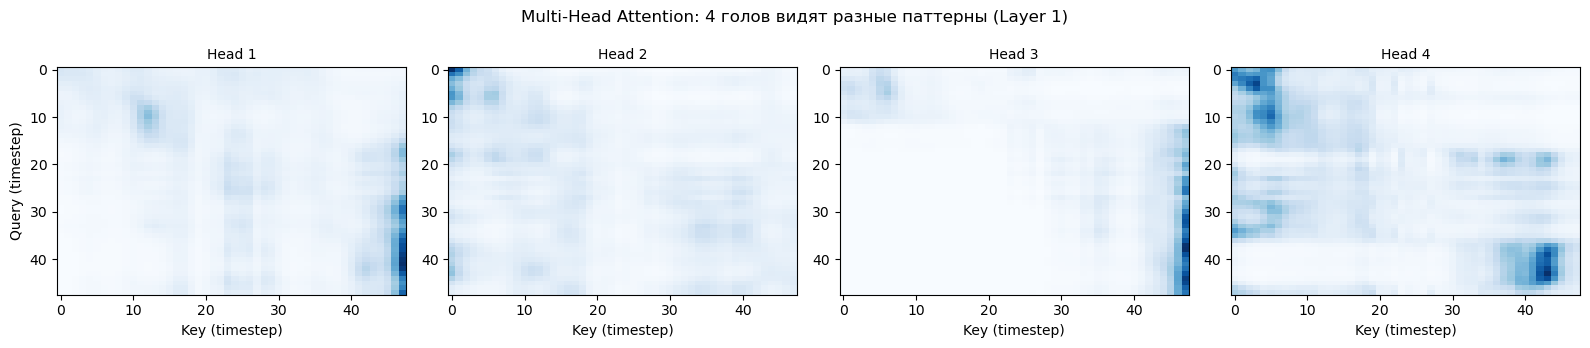

Каждая голова учится обращать внимание на разные аспекты:
— одна может фокусироваться на недавних шагах (диагональ)
— другая на экстремальных значениях
— третья на периодических паттернах


In [19]:
idx = up_indices[0]
seq = torch.tensor(X_test_norm[idx:idx+1], dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    attn_list = extractor.extract_attention(seq)

attn_layer0 = attn_list[0][0]
nhead = attn_layer0.shape[0]

fig, axes = plt.subplots(1, nhead, figsize=(4 * nhead, 3.5))
for h in range(nhead):
    im = axes[h].imshow(attn_layer0[h].numpy(), aspect='auto', cmap='Blues')
    axes[h].set_title(f'Head {h+1}', fontsize=10)
    axes[h].set_xlabel('Key (timestep)')
    if h == 0:
        axes[h].set_ylabel('Query (timestep)')

plt.suptitle(f'Multi-Head Attention: {nhead} голов видят разные паттерны (Layer 1)', fontsize=12)
plt.tight_layout(); plt.show()
print('Каждая голова учится обращать внимание на разные аспекты:')
print('— одна может фокусироваться на недавних шагах (диагональ)')
print('— другая на экстремальных значениях')
print('— третья на периодических паттернах')

In [20]:
class PriceLSTM(nn.Module):
    def __init__(self, input_size=4, hidden_size=64, num_layers=1, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True,
                          dropout=dropout if num_layers > 1 else 0)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 32), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(32, 1))
    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.classifier(h_n[-1]).squeeze(-1)

class PriceCNN(nn.Module):
    def __init__(self, in_channels=4, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2))
        self.conv2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2))
        self.conv3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU())
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(128, 1))
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.gap(x).squeeze(-1)
        return self.classifier(x).squeeze(-1)

lstm_path = MODELS / 'price_lstm_v1.pt'
cnn_path = MODELS / 'price_cnn_v1.pt'

preds_dict = {'Transformer': test_preds_tf}

if lstm_path.exists():
    lstm_model = PriceLSTM(input_size=N_FEATURES).to(DEVICE)
    lstm_model.load_state_dict(torch.load(lstm_path, weights_only=True))
    lstm_model.eval()

    lstm_preds = []
    with torch.no_grad():
        for X_b, _ in test_loader:
            logits = lstm_model(X_b.to(DEVICE))
            lstm_preds.append(torch.sigmoid(logits).cpu().numpy())
    preds_dict['LSTM'] = np.concatenate(lstm_preds)
    print(f'LSTM loaded: AUC={roc_auc_score(y_test, preds_dict["LSTM"]):.4f}')

if cnn_path.exists():
    cnn_model = PriceCNN(in_channels=N_FEATURES).to(DEVICE)
    cnn_model.load_state_dict(torch.load(cnn_path, weights_only=True))
    cnn_model.eval()

    cnn_preds = []
    with torch.no_grad():
        for X_b, _ in test_loader:
            X_cnn = X_b.transpose(1, 2).to(DEVICE)
            logits = cnn_model(X_cnn)
            cnn_preds.append(torch.sigmoid(logits).cpu().numpy())
    preds_dict['CNN'] = np.concatenate(cnn_preds)
    print(f'CNN loaded:  AUC={roc_auc_score(y_test, preds_dict["CNN"]):.4f}')

print(f'\nModels for ensemble: {list(preds_dict.keys())}')

LSTM loaded: AUC=0.6598


CNN loaded:  AUC=0.6685

Models for ensemble: ['Transformer', 'LSTM', 'CNN']


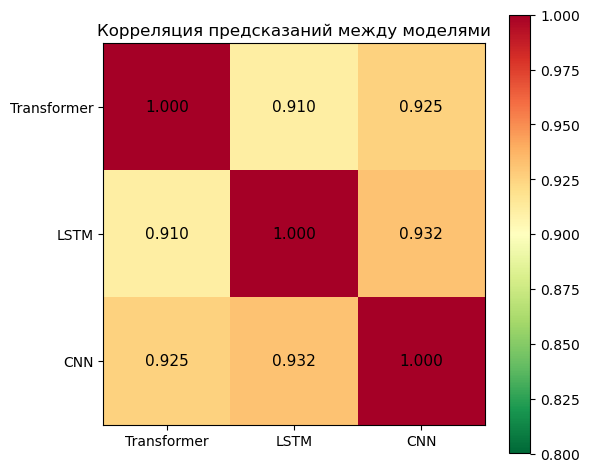

Низкая корреляция = модели видят разное → ensemble полезнее.
Высокая корреляция = модели согласны → ensemble мало что добавит.


In [21]:
model_names = list(preds_dict.keys())
n_models = len(model_names)

corr_matrix = np.zeros((n_models, n_models))
for i, n1 in enumerate(model_names):
    for j, n2 in enumerate(model_names):
        corr_matrix[i, j] = np.corrcoef(preds_dict[n1], preds_dict[n2])[0, 1]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap='RdYlGn_r', vmin=0.8, vmax=1.0)
ax.set_xticks(range(n_models)); ax.set_xticklabels(model_names)
ax.set_yticks(range(n_models)); ax.set_yticklabels(model_names)
for i in range(n_models):
    for j in range(n_models):
        ax.text(j, i, f'{corr_matrix[i,j]:.3f}', ha='center', va='center', fontsize=11)
plt.colorbar(im, ax=ax)
ax.set_title('Корреляция предсказаний между моделями')
plt.tight_layout(); plt.show()

print('Низкая корреляция = модели видят разное → ensemble полезнее.')
print('Высокая корреляция = модели согласны → ensemble мало что добавит.')

In [22]:
if len(preds_dict) >= 3:

    all_preds = np.stack(list(preds_dict.values()))
    ensemble_avg = all_preds.mean(axis=0)
    ensemble_auc = roc_auc_score(y_test, ensemble_avg)
    ensemble_acc = accuracy_score(y_test, (ensemble_avg > 0.5).astype(int))
    results['Ensemble (3-model avg)'] = {'auc': ensemble_auc, 'acc': ensemble_acc}
    print(f'Ensemble (LSTM+CNN+TF avg): AUC={ensemble_auc:.4f}, Acc={ensemble_acc:.1%}')

    best_combo_auc = 0
    best_weights = None
    for w_lstm in np.arange(0.0, 0.6, 0.1):
        for w_cnn in np.arange(0.0, 0.6, 0.1):
            w_tf = 1.0 - w_lstm - w_cnn
            if w_tf < 0:
                continue
            ens = (w_lstm * preds_dict['LSTM'] + w_cnn * preds_dict['CNN'] +
                   w_tf * preds_dict['Transformer'])
            auc = roc_auc_score(y_test, ens)
            if auc > best_combo_auc:
                best_combo_auc = auc
                best_weights = (w_lstm, w_cnn, w_tf)

    w_l, w_c, w_t = best_weights
    weighted_preds = (w_l * preds_dict['LSTM'] + w_c * preds_dict['CNN'] +
                      w_t * preds_dict['Transformer'])
    weighted_auc = roc_auc_score(y_test, weighted_preds)
    weighted_acc = accuracy_score(y_test, (weighted_preds > 0.5).astype(int))
    results['Weighted (3-model)'] = {'auc': weighted_auc, 'acc': weighted_acc}

    print(f'Weighted (L={w_l:.1f}, C={w_c:.1f}, T={w_t:.1f}): AUC={weighted_auc:.4f}, Acc={weighted_acc:.1%}')
else:
    print(f'Only {len(preds_dict)} models available — need LSTM + CNN + Transformer for full ensemble')

Ensemble (LSTM+CNN+TF avg): AUC=0.6702, Acc=68.0%


Weighted (L=0.0, C=0.5, T=0.5): AUC=0.6713, Acc=68.0%


Model                                Accuracy          AUC
ResCNN (nb04)                          0.6800       0.6754
Weighted (3-model)                     0.6800       0.6713
Ensemble (3-model avg)                 0.6802       0.6702
CLS Transformer                        0.6775       0.6696
Deep Transformer                       0.6772       0.6686
CNN (nb04)                             0.6790       0.6685
Transformer (baseline)                 0.6789       0.6683
GRU (nb03)                             0.6780       0.6661
LSTM (nb03)                            0.6780       0.6598
Mean Reversion                         0.6636       0.5585
Random                                 0.5000       0.5000
Causal Transformer                     0.6670       0.5000


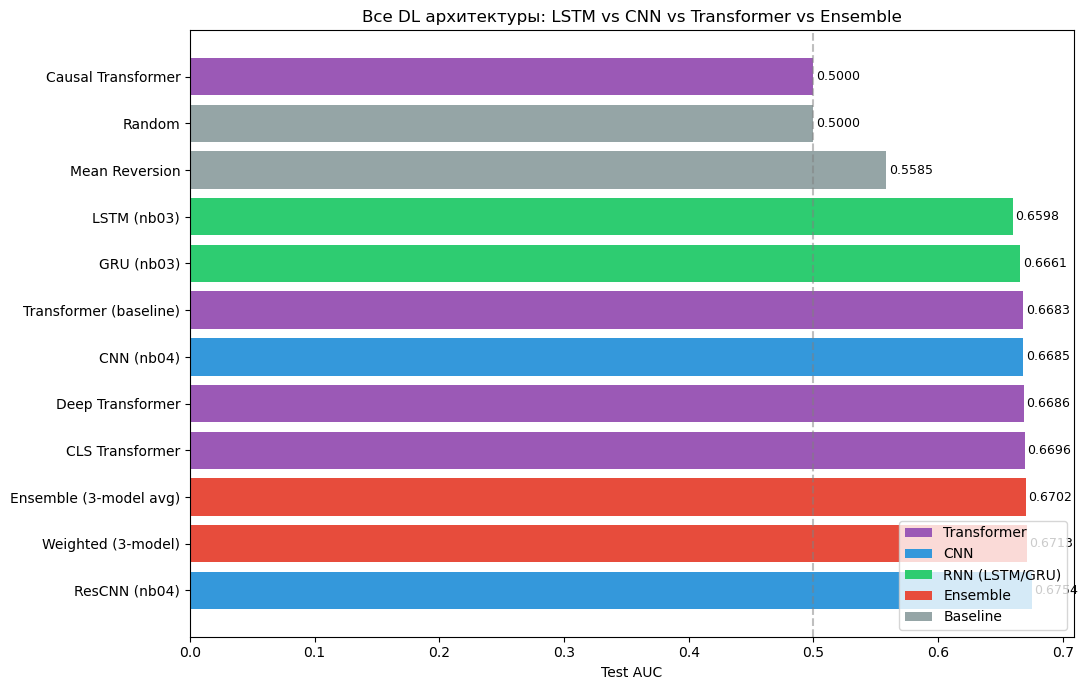

In [23]:
print('=' * 65)
print(f'{"Model":<32} {"Accuracy":>12} {"AUC":>12}')
print('=' * 65)

sorted_results = sorted(results.items(), key=lambda x: x[1]['auc'], reverse=True)
for name, metrics in sorted_results:
    print(f'{name:<32} {metrics["acc"]:>12.4f} {metrics["auc"]:>12.4f}')
print('=' * 65)

fig, ax = plt.subplots(figsize=(11, 7))
names = [r[0] for r in sorted_results]
aucs = [r[1]['auc'] for r in sorted_results]

def get_color(name):
    if 'Ensemble' in name or 'Weighted' in name:
        return '#e74c3c'
    elif 'Transformer' in name or 'CLS' in name or 'Causal' in name or 'Deep' in name:
        return '#9b59b6'
    elif 'CNN' in name or 'Res' in name:
        return '#3498db'
    elif 'LSTM' in name or 'GRU' in name:
        return '#2ecc71'
    return '#95a5a6'

colors = [get_color(n) for n in names]
bars = ax.barh(names, aucs, color=colors)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Test AUC')
ax.set_title('Все DL архитектуры: LSTM vs CNN vs Transformer vs Ensemble')

for bar, auc in zip(bars, aucs):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{auc:.4f}', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#9b59b6', label='Transformer'),
    Patch(facecolor='#3498db', label='CNN'),
    Patch(facecolor='#2ecc71', label='RNN (LSTM/GRU)'),
    Patch(facecolor='#e74c3c', label='Ensemble'),
    Patch(facecolor='#95a5a6', label='Baseline'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout(); plt.show()

In [24]:
print('\n=== Сравнение архитектур для time series ===')
print(f'{"":<20} {"LSTM":<15} {"CNN":<15} {"Transformer":<15}')
print('-' * 65)
print(f'{"Обработка":<20} {"Sequential":<15} {"Parallel":<15} {"Parallel":<15}')
print(f'{"Видит":<20} {"Все шаги":<15} {"Локально":<15} {"Все шаги":<15}')
print(f'{"Расстояние":<20} {"O(T)":<15} {"O(T/k)":<15} {"O(1)":<15}')
print(f'{"Параметры":<20} {"~15K":<15} {"~37K":<15} {"~30K":<15}')
print(f'{"Скорость":<20} {"Медленно":<15} {"Быстро":<15} {"Средне":<15}')
print(f'{"Интерпретация":<20} {"Hidden state":<15} {"Feature maps":<15} {"Attn weights":<15}')
print(f'{"Плюсы":<20} {"Долгие завис.":<15} {"Лок. паттерны":<15} {"Гибкость":<15}')
print(f'{"Минусы":<20} {"Не параллел.":<15} {"Огр. поле":<15} {"Нужно больше":<15}')
print(f'{"":<20} {"":<15} {"зрения":<15} {"данных":<15}')


=== Сравнение архитектур для time series ===
                     LSTM            CNN             Transformer    
-----------------------------------------------------------------
Обработка            Sequential      Parallel        Parallel       
Видит                Все шаги        Локально        Все шаги       
Расстояние           O(T)            O(T/k)          O(1)           
Параметры            ~15K            ~37K            ~30K           
Скорость             Медленно        Быстро          Средне         
Интерпретация        Hidden state    Feature maps    Attn weights   
Плюсы                Долгие завис.   Лок. паттерны   Гибкость       
Минусы               Не параллел.    Огр. поле       Нужно больше   
                                     зрения          данных         
